In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from qiskit.circuit.library import EfficientSU2
from qiskit.quantum_info import SparsePauliOp, Statevector
from qiskit.primitives import StatevectorEstimator
from qiskit_algorithms.optimizers import COBYLA, QNSPSA
import time
import matplotlib

# Visual configuration for plots
plt.style.use('seaborn-v0_8-whitegrid')

In the next cell, we will compare a circuit without any good choice of BP reduction vs a circuit with a good choice of BP reduction.

/tmp/ipykernel_94433/2195091455.py:12: DeprecationWarning: The class ``qiskit.circuit.library.n_local.efficient_su2.EfficientSU2`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. Use the function qiskit.circuit.library.efficient_su2 instead.
  ansatz = EfficientSU2(num_qubits=n_qubits, reps=reps_log, entanglement='linear')


Iniciando optimización. Qubits: 8, Parámetros: 64, Profundidad: 3
Iteración 0  | Coste: 0.967827 | Norma Grad: 0.278787
Iteración 5  | Coste: -0.507269 | Norma Grad: 0.737454
Iteración 10 | Coste: -0.976686 | Norma Grad: 0.147968
Iteración 15 | Coste: -0.997595 | Norma Grad: 0.041434
Iteración 20 | Coste: -0.999635 | Norma Grad: 0.015529

[Early Stopping] Convergencia alcanzada en la iteración 22.
Diferencia de coste (0.000076) inferior a la tolerancia (0.0001).


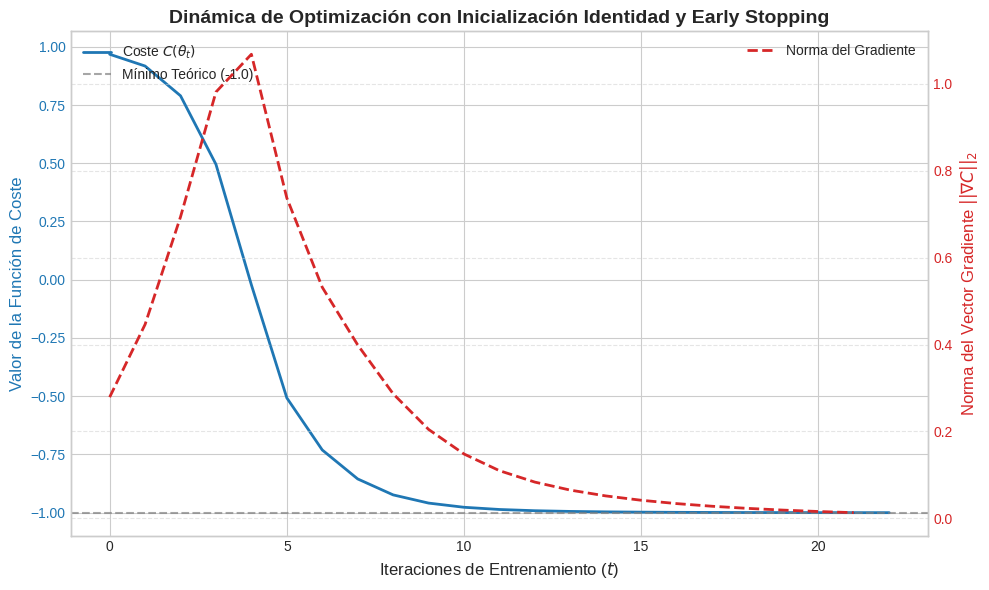

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from qiskit.circuit.library import EfficientSU2
from qiskit.quantum_info import SparsePauliOp
from qiskit.primitives import StatevectorEstimator

# 1. Configuración del sistema estático
n_qubits = 8
reps_log = int(np.round(np.log2(n_qubits))) # Profundidad L = 3

# Arquitectura Mitigada
ansatz = EfficientSU2(num_qubits=n_qubits, reps=reps_log, entanglement='linear')
observable = SparsePauliOp.from_list([("I" * (n_qubits - 1) + "Z", 1)])
num_params = ansatz.num_parameters
estimator = StatevectorEstimator()

# 2. Inicialización Identidad (Cercana a cero)
theta_t = np.random.normal(loc=0.0, scale=0.1, size=num_params)

# Hiperparámetros del Optimizador (Gradient Descent)
learning_rate = 0.5
max_iterations = 60
tolerance = 1e-4  # Umbral para el early stopping (épsilon)

history_cost = []
history_grad_norm = []

print(f"Iniciando optimización. Qubits: {n_qubits}, Parámetros: {num_params}, Profundidad: {reps_log}")

# 3. Bucle de Entrenamiento (Dinámica Temporal con Early Stopping)
for t in range(max_iterations):
    # Calcular el valor esperado (Coste)
    job_cost = estimator.run([(ansatz, observable, [theta_t])])
    current_cost = job_cost.result()[0].data.evs[0]
    history_cost.append(current_cost)
    
    # Evaluar condición de Early Stopping
    if t > 0:
        cost_diff = abs(history_cost[t-1] - current_cost)
        if cost_diff < tolerance:
            print(f"\n[Early Stopping] Convergencia alcanzada en la iteración {t}.")
            print(f"Diferencia de coste ({cost_diff:.6f}) inferior a la tolerancia ({tolerance}).")
            break
            
    # Calcular el vector gradiente exacto (Parameter-Shift Rule)
    gradient_vector = np.zeros(num_params)
    pubs = []
    
    for i in range(num_params):
        p_plus = theta_t.copy()
        p_minus = theta_t.copy()
        p_plus[i] += np.pi / 2
        p_minus[i] -= np.pi / 2
        pubs.append((ansatz, observable, [p_plus, p_minus]))
        
    job_grad = estimator.run(pubs)
    results = job_grad.result()
    
    for i in range(num_params):
        gradient_vector[i] = 0.5 * (results[i].data.evs[0] - results[i].data.evs[1])
        
    # Registrar la magnitud del gradiente (Norma L2)
    grad_norm = np.linalg.norm(gradient_vector)
    history_grad_norm.append(grad_norm)
    
    # Regla de actualización: Descenso de Gradiente
    theta_t = theta_t - learning_rate * gradient_vector

    if t % 5 == 0:
        print(f"Iteración {t:<2} | Coste: {current_cost:.6f} | Norma Grad: {grad_norm:.6f}")

# 4. Gráficas de la Dinámica Temporal
fig, ax1 = plt.subplots(figsize=(10, 6))

color1 = 'tab:blue'
ax1.set_xlabel('Iteraciones de Entrenamiento ($t$)', fontsize=12)
ax1.set_ylabel('Valor de la Función de Coste', color=color1, fontsize=12)
# Ajustamos el rango del eje X al número real de iteraciones ejecutadas
iteraciones_reales = len(history_cost)
ax1.plot(range(iteraciones_reales), history_cost, '-', color=color1, linewidth=2, label='Coste $C(\\theta_t)$')
ax1.tick_params(axis='y', labelcolor=color1)
ax1.axhline(y=-1.0, color='gray', linestyle='--', alpha=0.7, label='Mínimo Teórico (-1.0)')
ax1.legend(loc='upper left')

ax2 = ax1.twinx()  
color2 = 'tab:red'
ax2.set_ylabel('Norma del Vector Gradiente $||\\nabla C||_2$', color=color2, fontsize=12)
# La lista de normas del gradiente tiene un elemento menos que la de costes si se activa el early stopping
ax2.plot(range(len(history_grad_norm)), history_grad_norm, '--', color=color2, linewidth=2, label='Norma del Gradiente')
ax2.tick_params(axis='y', labelcolor=color2)
ax2.legend(loc='upper right')

plt.title('Dinámica de Optimización con Inicialización Identidad y Early Stopping', fontsize=14, fontweight='bold')
plt.grid(True, linestyle='--', alpha=0.5)
fig.tight_layout()
plt.show()

Starting Comparative Barren Plateau Simulation (Scaling up to 20 qubits)...


/tmp/ipykernel_94433/278415557.py:27: DeprecationWarning: The class ``qiskit.circuit.library.n_local.efficient_su2.EfficientSU2`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. Use the function qiskit.circuit.library.efficient_su2 instead.
  ansatz_A = EfficientSU2(num_qubits=n, reps=3, entanglement='full')
/tmp/ipykernel_94433/278415557.py:33: DeprecationWarning: The class ``qiskit.circuit.library.n_local.efficient_su2.EfficientSU2`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. Use the function qiskit.circuit.library.efficient_su2 instead.
  ansatz_B = EfficientSU2(num_qubits=n, reps=reps_log, entanglement='linear')


Qubits: 2  | Reps_B: 1 | Var Worst: 0.12214282 | Var Mitigated: 0.0094 | Time: 2.13 s
Qubits: 4  | Reps_B: 2 | Var Worst: 0.02312449 | Var Mitigated: 0.0099 | Time: 2.37 s
Qubits: 6  | Reps_B: 3 | Var Worst: 0.00808786 | Var Mitigated: 0.0076 | Time: 2.86 s
Qubits: 8  | Reps_B: 3 | Var Worst: 0.00088587 | Var Mitigated: 0.0085 | Time: 6.77 s
Qubits: 10 | Reps_B: 3 | Var Worst: 0.00028851 | Var Mitigated: 0.0098 | Time: 7.78 s
Qubits: 12 | Reps_B: 4 | Var Worst: 0.00010726 | Var Mitigated: 0.0101 | Time: 16.12 s
Qubits: 14 | Reps_B: 4 | Var Worst: 0.00003938 | Var Mitigated: 0.0075 | Time: 23.29 s

Simulation finished in 61.33 seconds.


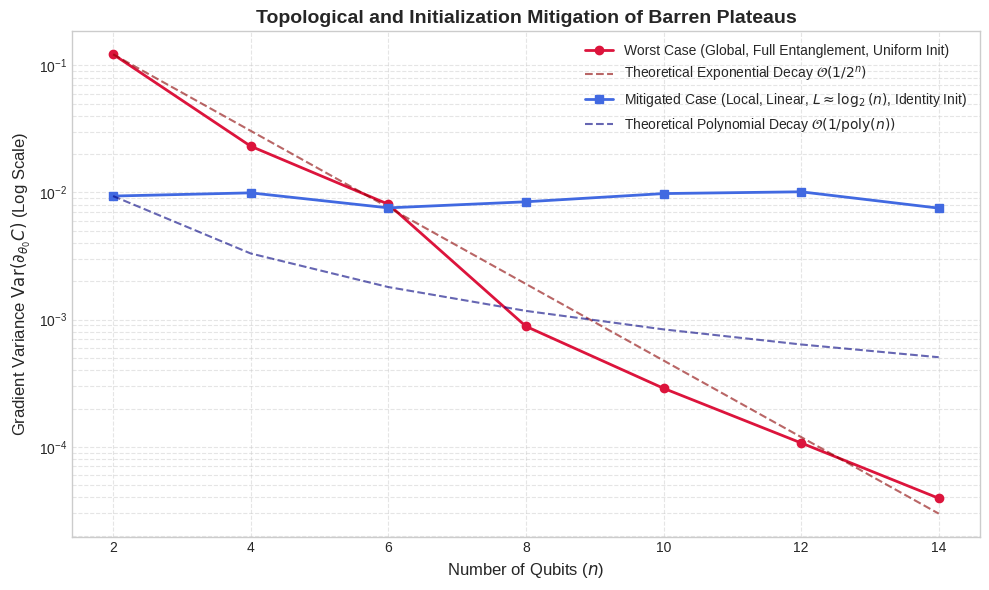

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import time
from qiskit.circuit.library import EfficientSU2
from qiskit.quantum_info import SparsePauliOp
from qiskit.primitives import StatevectorEstimator

# 1. Configuration
# Expanded up to 20 qubits as requested. 
# Note: Simulating a 20-qubit statevector (2^20 amplitudes) requires significant 
# classical RAM and time. num_samples is kept at 100 to balance computation.
qubit_list = [2, 4, 6, 8, 10, 12, 14]
num_samples = 100
estimator = StatevectorEstimator()

variances_worst_case = []
variances_mitigated_case = []

print("Starting Comparative Barren Plateau Simulation (Scaling up to 20 qubits)...")
start_total = time.time()

for n in qubit_list:
    start_q = time.time()

    # --- ARCHITECTURE A: THE WORST CASE ---
    # Global Cost, Full Entanglement, Constant Depth
    ansatz_A = EfficientSU2(num_qubits=n, reps=3, entanglement='full')
    observable_A = SparsePauliOp.from_list([("Z" * n, 1)]) 
    
    # --- ARCHITECTURE B: THE MITIGATED CASE ---
    # Local Cost, Linear Entanglement, Logarithmic Depth O(log n)
    reps_log = max(1, int(np.round(np.log2(n))))
    ansatz_B = EfficientSU2(num_qubits=n, reps=reps_log, entanglement='linear')
    observable_B = SparsePauliOp.from_list([("I" * (n - 1) + "Z", 1)]) 
    
    grads_A = []
    grads_B = []

    for _ in range(num_samples):
        # Worst Case: Random uniform initialization mapping to the Haar measure
        params_A = np.random.uniform(-np.pi, np.pi, ansatz_A.num_parameters)
        
        # Mitigated Case: Identity Initialization
        # We sample from a narrow Gaussian centered at 0 to measure the local variance
        # representing the start of the optimization trajectory.
        params_B = np.random.normal(loc=0.0, scale=0.1, size=ansatz_B.num_parameters)

        # Parameter-shift rule (evaluating the partial derivative wrt the first parameter)
        p_plus_A, p_minus_A = params_A.copy(), params_A.copy()
        p_plus_A[0] += np.pi / 2
        p_minus_A[0] -= np.pi / 2
        
        p_plus_B, p_minus_B = params_B.copy(), params_B.copy()
        p_plus_B[0] += np.pi / 2
        p_minus_B[0] -= np.pi / 2

        # Primitive execution
        job_A = estimator.run([(ansatz_A, observable_A, [p_plus_A, p_minus_A])])
        job_B = estimator.run([(ansatz_B, observable_B, [p_plus_B, p_minus_B])])
        
        res_A = job_A.result()[0].data.evs
        res_B = job_B.result()[0].data.evs

        grads_A.append(0.5 * (res_A[0] - res_A[1]))
        grads_B.append(0.5 * (res_B[0] - res_B[1]))

    # Calculate and store the statistical variance
    var_A = np.var(grads_A)
    var_B = np.var(grads_B)
    
    variances_worst_case.append(var_A)
    variances_mitigated_case.append(var_B)

    print(f"Qubits: {n:<2} | Reps_B: {reps_log} | Var Worst: {var_A:.8f} | Var Mitigated: {var_B:.4f} | Time: {time.time() - start_q:.2f} s")

print(f"\nSimulation finished in {time.time() - start_total:.2f} seconds.")

# 2. Plotting the Mathematical Contrast
plt.figure(figsize=(10, 6))

# Worst Case Plot
plt.plot(qubit_list, variances_worst_case, 'o-', color='crimson', linewidth=2, label='Worst Case (Global, Full Entanglement, Uniform Init)')
ref_exp = [variances_worst_case[0] * (2 ** (qubit_list[0] - n)) for n in qubit_list]
plt.plot(qubit_list, ref_exp, '--', color='darkred', alpha=0.6, label='Theoretical Exponential Decay $\\mathcal{O}(1/2^n)$')

# Mitigated Case Plot
plt.plot(qubit_list, variances_mitigated_case, 's-', color='royalblue', linewidth=2, label='Mitigated Case (Local, Linear, $L \\approx \\log_2(n)$, Identity Init)')
ref_poly = [variances_mitigated_case[0] * ((qubit_list[0] / n) ** 1.5) for n in qubit_list] 
plt.plot(qubit_list, ref_poly, '--', color='navy', alpha=0.6, label='Theoretical Polynomial Decay $\\mathcal{O}(1/\\text{poly}(n))$')

plt.yscale('log')
plt.title('Topological and Initialization Mitigation of Barren Plateaus', fontsize=14, fontweight='bold')
plt.xlabel('Number of Qubits ($n$)', fontsize=12)
plt.ylabel('Gradient Variance $\\text{Var}(\\partial_{\\theta_0} C)$ (Log Scale)', fontsize=12)
plt.xticks(qubit_list)
plt.legend(fontsize=10)
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.tight_layout()
plt.show()